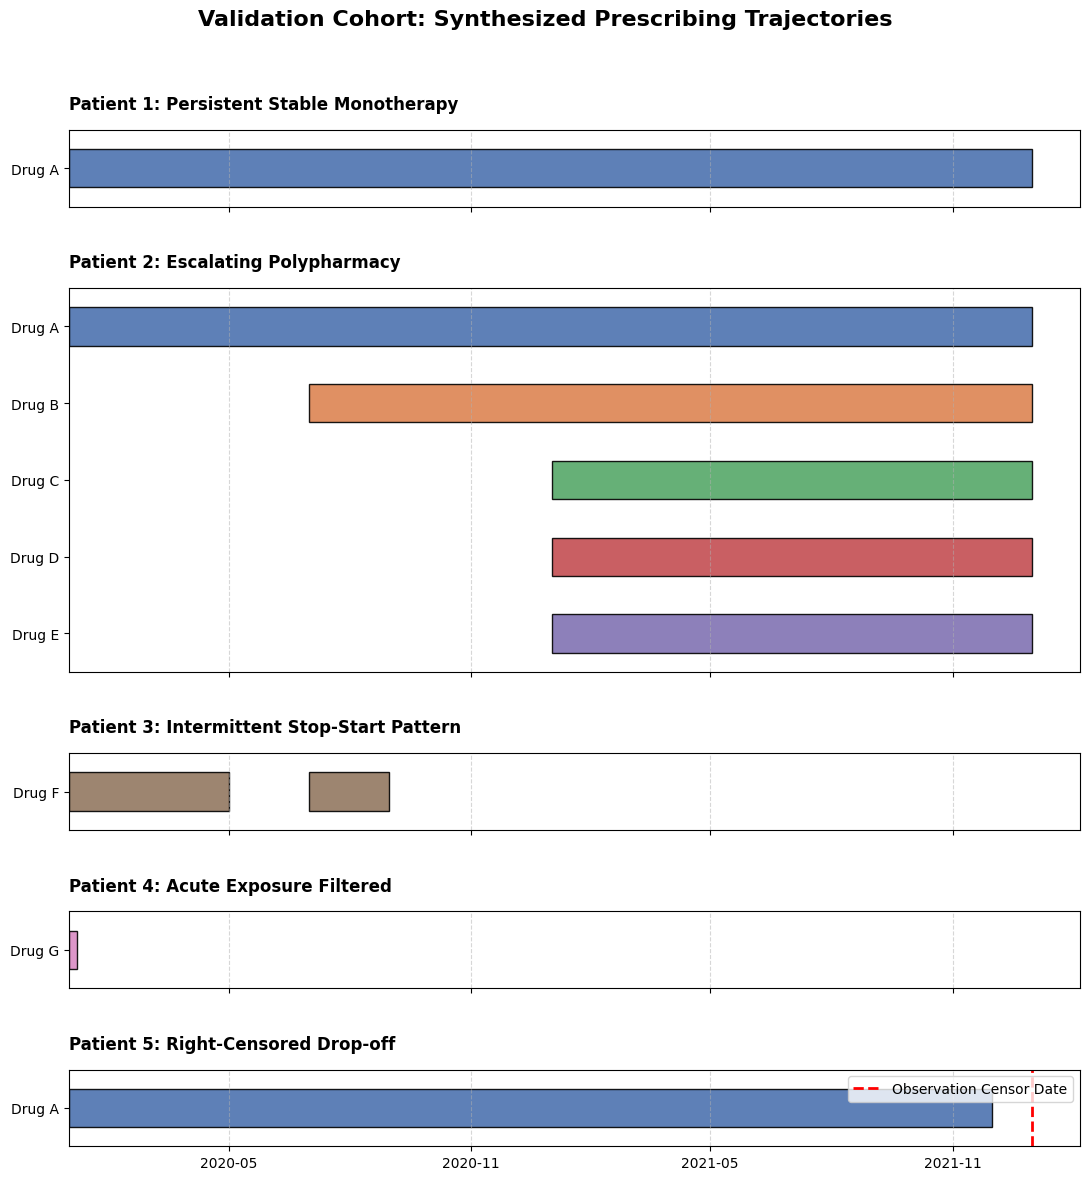

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 1. Load the exported eras
eras_df = pd.read_parquet("../data/validation_outputs/eras.parquet")

# Map concept IDs to readable names
drug_map = {
    101: 'Drug A', 102: 'Drug B', 103: 'Drug C', 104: 'Drug D', 
    105: 'Drug E', 106: 'Drug F', 107: 'Drug G'
}

colors = {101: '#4c72b0', 102: '#dd8452', 103: '#55a868', 104: '#c44e52', 
          105: '#8172b3', 106: '#937860', 107: '#da8bc3'}

patient_labels = {
    1: "Patient 1: Persistent Stable Monotherapy",
    2: "Patient 2: Escalating Polypharmacy",
    3: "Patient 3: Intermittent Stop-Start Pattern",
    4: "Patient 4: Acute Exposure Filtered",
    5: "Patient 5: Right-Censored Drop-off"
}

# 2. Dynamically calculate subplot heights
patient_ids = [1, 2, 3, 4, 5]
unique_drugs = [eras_df[eras_df['person_id'] == pid]['ingredient_concept_id'].nunique() for pid in patient_ids]
height_ratios = [max(1, count) for count in unique_drugs]

# Increased overall height from 10 to 12 to give more vertical room
fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True, 
                         gridspec_kw={'height_ratios': height_ratios})

# Moved the main title slightly up
fig.suptitle("Validation Cohort: Synthesized Prescribing Trajectories", 
             fontsize=16, fontweight='bold', y=0.98)

# 4. Plot each patient's timeline
for ax, person_id in zip(axes, patient_ids):
    pt_data = eras_df[eras_df['person_id'] == person_id].copy()
    pt_data = pt_data.sort_values('era_start_date')
    
    plotted_drugs = []
    
    for _, row in pt_data.iterrows():
        start = mdates.date2num(row['era_start_date'])
        end = mdates.date2num(row['era_end_date'])
        concept = row['ingredient_concept_id']
        drug_name = drug_map.get(concept, f"Drug {concept}")
        
        if drug_name not in plotted_drugs:
            plotted_drugs.append(drug_name)
            
        y_pos = plotted_drugs.index(drug_name)
        
        ax.barh(y=y_pos, width=end-start, left=start, height=0.5, 
                color=colors.get(concept, 'grey'), edgecolor='black', alpha=0.9)
        
    # FIX: Added fontweight='bold' and increased pad=15 to push the title away from the graph
    ax.set_title(patient_labels[person_id], fontsize=12, fontweight='bold', pad=15, loc='left')
    
    # Lock the axes
    if len(plotted_drugs) > 0:
        ax.set_yticks(range(len(plotted_drugs)))
        ax.set_yticklabels(plotted_drugs)
        ax.set_ylim(-0.5, len(plotted_drugs) - 0.5)
        ax.invert_yaxis()

    # X-axis formatting
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    if person_id == 5:
        ax.axvline(pd.to_datetime("2021-12-31"), color='red', linestyle='--', 
                   linewidth=2, label="Observation Censor Date")
        ax.legend(loc="upper right")

# FIX: Force a large horizontal pad (h_pad=3.0) between rows and protect the main title
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)

# Save and Show
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/synthetic_validation_gantt.png", dpi=300, bbox_inches='tight')
plt.show()